In [11]:
# Librerie di base
import pandas as pd
import numpy as np
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [12]:


# Percorso del file (adatta il nome al tuo file)
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/progetto/Dati/all_centroids_w31.csv"

# Caricamento dati
df = pd.read_csv(data_path)

# Mostra le prime righe
df.head()


,id,species,stage,site,cycle,sex,age,capture_reg,capture_subreg,lon,...,from_sea,type,type2,count_ind_sp,weight,wt_sp,wt_dur,wt_sp_sex,wt_ind,wt_ind_sp
0,100431_1,BLSC,W,W1,1,M,ASY,Southern New England,Rhode Island,-70.211090,...,NaN,0,0,89,0,3.120704,0.041096,5.909524,0.066667,0.000749
1,100431_1,BLSC,W,W2,1,M,ASY,Southern New England,Rhode Island,-73.892804,...,W,WD,W,89,1,3.120704,0.279338,5.909524,0.066667,0.000749
2,100431_1,BLSC,S,S1,1,M,ASY,Southern New England,Rhode Island,-62.408619,...,W,SM,SM,89,1,3.120704,0.095890,5.909524,0.066667,0.000749
3,100431_1,BLSC,M,M1,1,M,ASY,Southern New England,Rhode Island,-80.532833,...,S,SM,SM,89,1,3.120704,0.271233,5.909524,0.066667,0.000749
4,100431_1,BLSC,M,M2,1,M,ASY,Southern New England,Rhode Island,-79.399203,...,F,MD,WM,89,1,3.120704,0.076712,5.909524,0.066667,0.000749


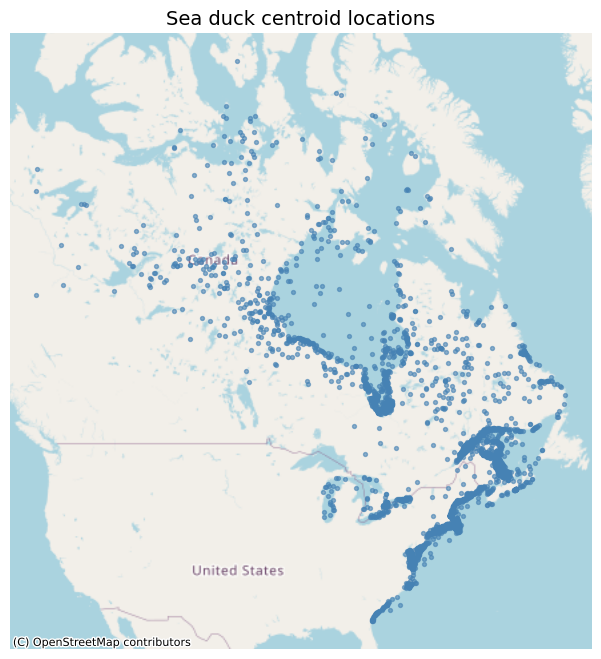

In [ ]:
# 1️⃣ Creiamo il GeoDataFrame dai centroidi
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"   # coordinate geografiche (lat/lon)
)
# 2️⃣ Convertiamo in proiezione metrica (necessaria per contextily)
gdf_proj = gdf.to_crs(epsg=3857)

# 3️⃣ Plot semplice
fig, ax = plt.subplots(figsize=(10, 8))
gdf_proj.plot(ax=ax, color="steelblue", markersize=8, alpha=0.6)

# 4️⃣ Aggiungiamo la mappa di sfondo (usiamo OpenStreetMap come alternativa)
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=3)

# 5️⃣ Miglioriamo il layout
ax.set_title("Sea duck centroid locations", fontsize=14)
ax.set_axis_off()

plt.show()

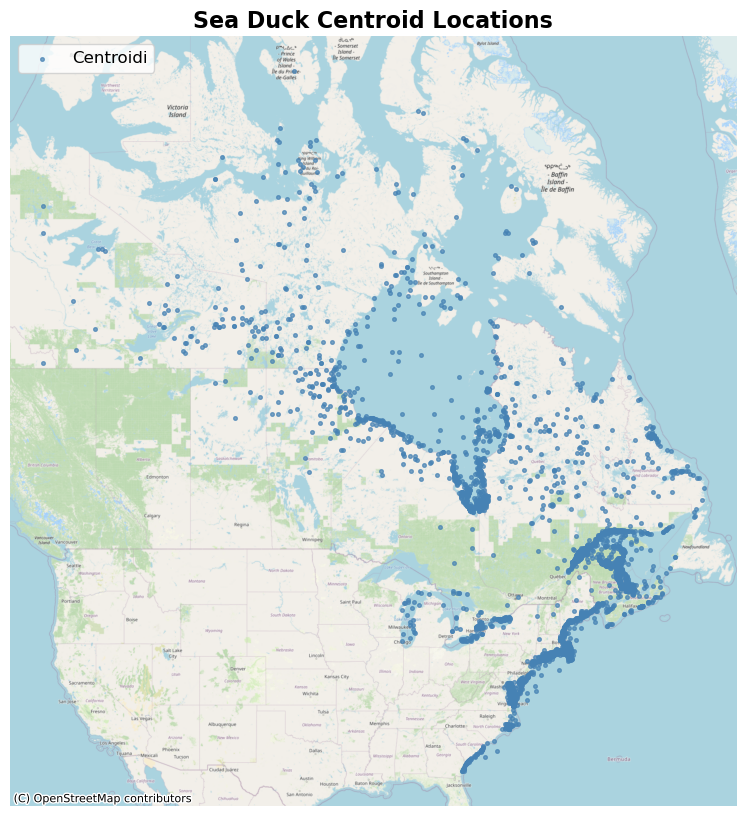

Numero di punti plottati: 3722


In [23]:
# 3️⃣ Plot migliorato
fig, ax = plt.subplots(figsize=(12, 10))

# Plot dei punti
gdf_proj.plot(
    ax=ax,
    color="steelblue",
    markersize=7,  # Dimensione dei punti
    alpha=0.7,
    label="Centroidi"  # Etichetta per la legenda
)

# 4️⃣ Aggiungiamo la mappa di sfondo
cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,  # Mappa di sfondo
    zoom=5  # Regola il livello di zoom
)

# 5️⃣ Miglioriamo il layout
ax.set_title("Sea Duck Centroid Locations", fontsize=16, fontweight="bold")
ax.set_axis_off()  # Rimuove gli assi
ax.legend(fontsize=12, loc="upper left")  # Aggiunge la legenda

# Salva il grafico come immagine (opzionale)
plt.savefig("sea_duck_centroids.png", dpi=300, bbox_inches="tight")

plt.show()

print(f"Numero di punti plottati: {len(gdf_proj)}")

Unique 'season' values: ['W' 'S' 'F' 'B']
Counts by season:
 season
W    1179
F    1106
S     975
B     462
Name: count, dtype: int64


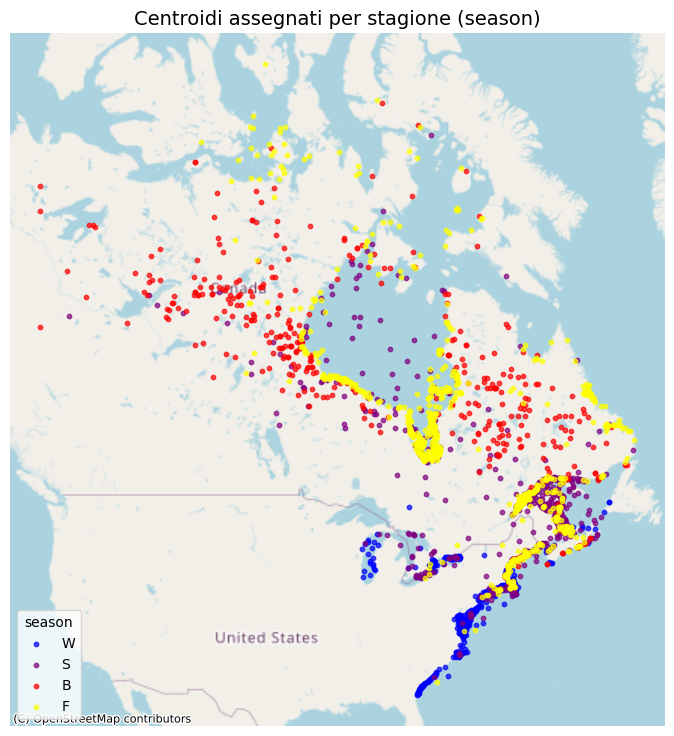

In [25]:
# Assumo che 'df' sia già caricato come pandas DataFrame
# Creiamo il GeoDataFrame (riconverti se necessario)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

# Controllo rapidi sui valori unici (facoltativo ma utile)
print("Unique 'season' values:", gdf['season'].unique())
print("Counts by season:\n", gdf['season'].value_counts())

# Mappatura colori coerente con il paper
season_color = {
    'W': 'blue',   # winter
    'S': 'purple', # spring migration / spring staging
    'B': 'red',    # breeding
    'F': 'yellow'  # fall (post-breeding molt / fall staging)
}

# Se la colonna 'season' contiene parole complete (es. 'winter'), adattalo:
# season_color = {'winter':'blue','spring':'purple','breeding':'red','fall':'yellow'}

# Convertiamo CRS per la basemap
gdf_proj = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(11, 9))
for code, color in season_color.items():
    subset = gdf_proj[gdf_proj['season'] == code]
    if len(subset):
        subset.plot(ax=ax, color=color, markersize=10, alpha=0.7, label=code)

# Aggiungi basemap e sistemazione grafica
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=3)
ax.set_title("Centroidi assegnati per stagione (season)", fontsize=14)
ax.set_axis_off()
ax.legend(title='season', loc='lower left')

plt.show()


Unique 'season' values: ['W' 'S' 'F' 'B']
Counts by season:
 season
W    1179
F    1106
S     975
B     462
Name: count, dtype: int64


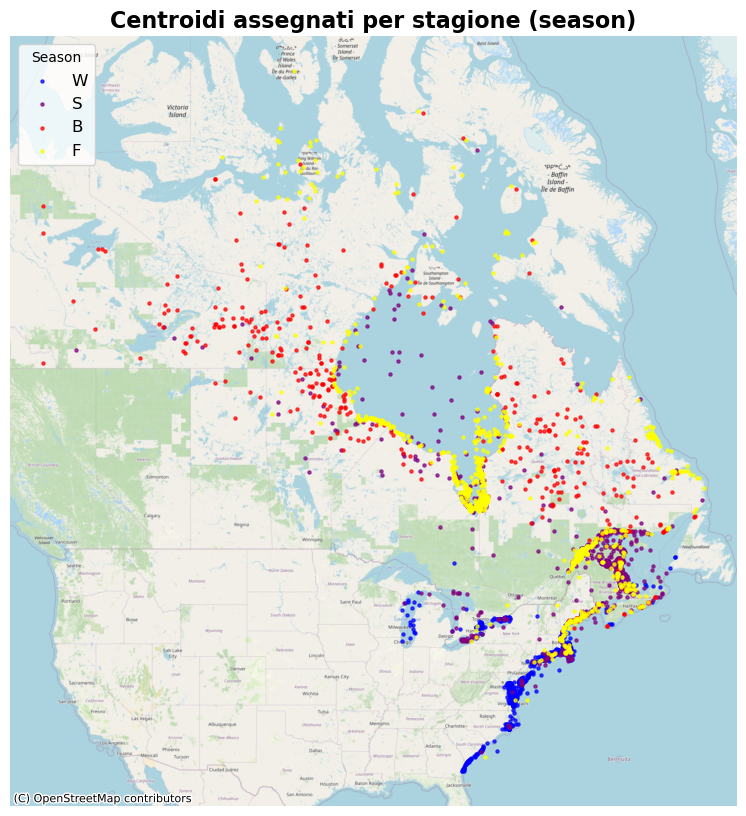

In [31]:
# Creiamo il GeoDataFrame (riconverti se necessario)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

# Controllo rapidi sui valori unici (facoltativo ma utile)
print("Unique 'season' values:", gdf['season'].unique())
print("Counts by season:\n", gdf['season'].value_counts())

# Mappatura colori coerente con il paper
season_color = {
    'W': 'blue',   # winter
    'S': 'purple', # spring migration / spring staging
    'B': 'red',    # breeding
    'F': 'yellow'  # fall (post-breeding molt / fall staging)
}

# Convertiamo CRS per la basemap
gdf_proj = gdf.to_crs(epsg=3857)

# Plot migliorato
fig, ax = plt.subplots(figsize=(12, 10))

# Plot dei punti per ogni stagione
for code, color in season_color.items():
    subset = gdf_proj[gdf_proj['season'] == code]
    if len(subset):
        subset.plot(ax=ax, color=color, markersize=5, alpha=0.7, label=code)

# Aggiungiamo la mappa di sfondo
cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,  # Mappa di sfondo
    zoom=5  # Regola il livello di zoom
)

# Miglioriamo il layout
ax.set_title("Centroidi assegnati per stagione (season)", fontsize=16, fontweight="bold")
ax.set_axis_off()  # Rimuove gli assi
ax.legend(title='Season', fontsize=12, loc="upper left")  # Aggiunge la legenda

# Salva il grafico come immagine (opzionale)
plt.savefig("season_centroids_map.png", dpi=300, bbox_inches="tight")

plt.show()